# Portfolio Design Readiness

## TL;DR

- The development feature registry retains **113 of 116 features** and removes only **3** calculations: two exact duplicates and one cross-instrument-degenerate minute-return median.
- Point-in-time preprocessing yields **2,473 complete symbol-session rows** using only prior observations for bounds and scaling.
- Forward labels for 1, 5, and 20 sessions are stored separately from features and become available only at their realization timestamps.
- **4 expanding development folds** include five-session embargoes. The sealed one-year holdout remains outside this workflow.
- The portfolio policy preserves correlated instruments, supports long/short allocations, and requires transaction-cost, liquidity, and roll-method inputs before evaluation.
- No portfolio backtest or performance optimization has been run.


## Context & Methods

This notebook verifies that the research inputs are ready for portfolio specification. It checks selection, point-in-time transformations, label separation, walk-forward boundaries, and risk-policy defaults.

### Key Assumptions

- Features generated after a session close cannot affect that same session's return.
- Winsorization limits and median/IQR scaling use expanding observations strictly before the current row.
- Correlated instruments are retained intentionally; only redundant feature calculations are excluded.
- Current portfolio constraints are design defaults and must be reviewed before simulation.


In [1]:
from pathlib import Path
import json
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists(): ROOT = ROOT.parent
registry = pd.read_csv(ROOT / "data/catalog/feature_registry.csv")
folds = pd.read_csv(ROOT / "data/catalog/development_walk_forward_folds.csv")
processed = pd.read_parquet(ROOT / "data/processed/model_inputs/development_model_features.parquet")
labels = pd.read_parquet(ROOT / "data/processed/labels/development_forward_labels.parquet")
split = json.loads((ROOT / "data/catalog/temporal_split.json").read_text())
portfolio = yaml.safe_load((ROOT / "config/portfolio.yaml").read_text())["portfolio_design"]
assert not any("forward" in c or "target" in c for c in processed.columns)
assert pd.to_datetime(processed["trading_date"]).max() <= pd.Timestamp(split["development_end"])
print(f"Selected features: {registry['selected'].sum()} / {len(registry)}")
print(f"Complete model rows: {processed['model_row_complete'].sum():,} / {len(processed):,}")
print(f"Labels remain separate: {len(labels):,} rows | Folds: {len(folds)}")

Selected features: 113 / 116
Complete model rows: 2,473 / 3,673
Labels remain separate: 3,673 rows | Folds: 4


## Feature selection preserves breadth without exact duplication

In [2]:
selection = registry.groupby(["family", "selected"]).size().unstack(fill_value=0)
selection.columns = ["excluded" if not value else "selected" for value in selection.columns]
selection.sort_values("selected", ascending=False)

,excluded,selected
family,,
ohlcv_history,1,18
volatility_liquidity_regime,0,18
range_atr_and_estimators,0,15
minute_bar_pace_and_distribution,1,11
momentum_reversal,1,11
moving_average_structure,0,10
trend,0,9
linear_regression_structure,0,8
intraday_realized_risk,0,7


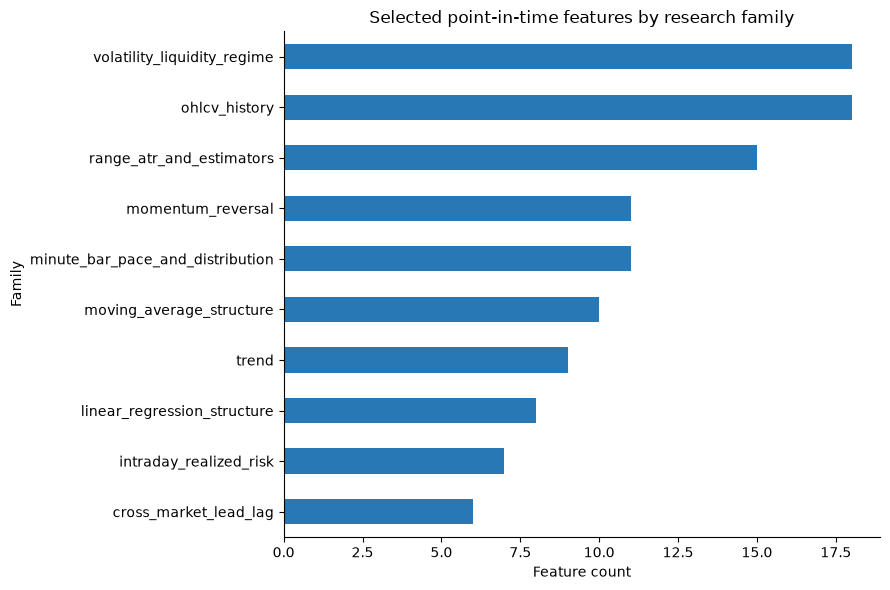

In [3]:
selected_by_family = registry.loc[registry["selected"]].groupby("family").size().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
selected_by_family.plot.barh(ax=ax, color="#2878B5")
ax.set(title="Selected point-in-time features by research family", xlabel="Feature count", ylabel="Family")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Preprocessing is causal and instrument-relative

In [4]:
completeness = processed.groupby("symbol")["model_row_complete"].agg(["sum", "count"])
completeness["complete_pct"] = completeness["sum"] / completeness["count"] * 100
completeness

,sum,count,complete_pct
symbol,,,
CLU6,494,734,67.302452
HGU6,494,734,67.302452
NQU6,495,735,67.346939
ZNU6,495,735,67.346939
ZTU6,495,735,67.346939


## Labels are isolated from the model matrix

In [5]:
label_columns = [column for column in labels if column.startswith("forward_log_return")]
label_summary = labels.groupby("symbol")[label_columns].count()
label_summary

,forward_log_return_1s,forward_log_return_5s,forward_log_return_20s
symbol,,,
CLU6,733,729,714
HGU6,733,729,714
NQU6,734,730,715
ZNU6,734,730,715
ZTU6,734,730,715


## Development folds enforce expanding training and embargoes

In [6]:
folds

,fold,train_start,train_end,embargo_start,embargo_end,validation_start,validation_end,train_sessions,validation_sessions
0,1,2022-10-12,2024-09-23,2024-09-24,2024-09-30,2024-10-01,2024-12-27,504,63
1,2,2022-10-12,2024-12-19,2024-12-20,2024-12-27,2024-12-30,2025-03-27,567,63
2,3,2022-10-12,2025-03-20,2025-03-21,2025-03-27,2025-03-28,2025-06-25,630,63
3,4,2022-10-12,2025-06-18,2025-06-19,2025-06-25,2025-06-26,2025-08-15,693,37


## Initial portfolio and risk specification

In [7]:
pd.json_normalize(portfolio, sep='.') .T.rename(columns={0: 'configured_value'})

,configured_value
status,design_only_no_backtest
direction,long_short
rebalance_frequency,daily
signal_lag_sessions,1
target_annualized_volatility,0.1
unavailable_until_more_data,"[ES, GC, 6J]"
covariance.method,exponentially_weighted
covariance.lookback_sessions,60
covariance.half_life_sessions,20
covariance.shrinkage,True


## Limitations and gates before evaluation

- Investor/RT continuation-series roll and adjustment rules remain unconfirmed.
- Transaction costs, slippage, roll costs, and instrument liquidity limits are not yet calibrated.
- ES and GC need older development history; 6J needs a valid nonconstant series.
- Feature retention is based on data integrity and redundancy—not predictive performance.
- The portfolio constraints are deliberately conservative starting points, not optimized results.


## Recommended portfolio-design sequence

1. Choose the first signal sleeves: time-series trend, short-term reversal, relative momentum, lead/lag, and correlation divergence.
2. Define how each sleeve converts standardized features into signed forecasts without using the holdout.
3. Combine sleeve forecasts, then apply volatility scaling and correlation-aware risk allocation.
4. Specify contract rounding, transaction costs, slippage, roll handling, and liquidity limits.
5. Evaluate only through the predefined development folds; freeze the full design before opening the sequential holdout simulator.
